<a href="https://colab.research.google.com/github/KRISHNA-EP18/Machine_Learning_IMLE/blob/main/SVD_Interpolation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MODULE 1 — INTRODUCTION & PROBLEM DEFINITION**

# Battery Discharge Curve Analysis Using NumPy, Interpolation and SVD

## Problem Definition

A battery discharge experiment gives us measurements such as:

- Time
- Voltage
- Current
- Temperature
- Capacity

However, different discharge cycles do not necessarily contain the same number of measurements.

For example:

- Cycle 1 → 197 voltage measurements
- Cycle 2 → 196 voltage measurements
- Cycle 3 → 195 voltage measurements
- Cycle 4 → 194 voltage measurements

This creates a problem when we want to construct a data matrix and apply machine-learning or dimensionality-reduction techniques such as Singular Value Decomposition (SVD).

SVD expects a rectangular numerical matrix.

Therefore, our main objective is:

1. Load battery discharge data.
2. Understand the structure of the MATLAB `.mat` file.
3. Extract voltage, time and capacity information.
4. Convert discharge curves with different lengths into a common representation.
5. Compare different interpolation/representation approaches.
6. Construct a common data matrix.
7. Apply SVD.
8. Determine how many SVD components are required.
9. Obtain a low-dimensional representation of each discharge cycle.
10. Use this representation to predict battery capacity.
11. Evaluate the prediction using MAE and R².

The important point is that interpolation is not the final objective.

Interpolation is only a preprocessing step that allows us to represent different discharge curves in a common coordinate system.

We will also see that not every representation works equally well.

In particular, we will compare simple interpolation, PCHIP, K-means-based interpolation, and DTW-based representations.

The goal is not to force one method to work.

The goal is to understand what happens when different representations are combined with SVD and machine learning.

**MODULE 2 — NUMPY + MATPLOTLIB**

# Module 2 — Introduction to NumPy

NumPy stands for Numerical Python.

It is one of the most important Python libraries for scientific computing.

Instead of storing numerical data as ordinary Python lists, NumPy allows us to work with arrays.

For example:

A Python list:

[1, 2, 3, 4]

A NumPy array:

np.array([1, 2, 3, 4])

The important difference is that NumPy arrays are designed for numerical operations.

We will use NumPy for:

- Creating numerical arrays
- Generating equally spaced values
- Vectorized calculations
- Broadcasting
- Matrix operations
- Solving linear equations
- Eigenvalue calculations
- SVD later in the tutorial

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)

NumPy version: 2.1.3


## Creating NumPy arrays

We can convert a Python list into a NumPy array using np.array().

Once we have an array, mathematical operations can be performed directly on the entire array.

In [ ]:
A = np.array([1, 2, 3, 4, 5])

print("A =", A)
print("Type =", type(A))
print("Shape =", A.shape)
print("Number of dimensions =", A.ndim)
print("Number of elements =", A.size)

A = [1 2 3 4 5]
Type = <class 'numpy.ndarray'>
Shape = (5,)
Number of dimensions = 1
Number of elements = 5


## Why NumPy is useful

Suppose we want to multiply every element by 2.

With a Python list, we would normally need a loop.

With NumPy, we can simply write:

A * 2

NumPy performs the operation element by element.

This is called vectorization.

In [ ]:
B = A * 2

print("Original A:", A)
print("A * 2:", B)

Original A: [1 2 3 4 5]
A * 2: [ 2  4  6  8 10]


## Broadcasting

Broadcasting allows NumPy to perform arithmetic between arrays of compatible shapes.

For example, if we multiply an array by a single number:

A * 2

the number 2 is conceptually applied to every element.

We can also add, subtract and divide arrays in the same way.

Broadcasting is extremely important when working with matrices and scientific data.

In [ ]:
A = np.array([1, 2, 3, 4, 5])



print("A + 10 =", A + 10)
print("A - 10 =", A - 10)
print("A * 10 =", A * 10)
print("A / 10 =", A / 10)

A + 10 = [11 12 13 14 15]
A - 10 = [-9 -8 -7 -6 -5]
A * 10 = [10 20 30 40 50]
A / 10 = [0.1 0.2 0.3 0.4 0.5]


## np.linspace()

np.linspace() generates a specified number of equally spaced points between two values.

For example:

np.linspace(0, 10, 6)

generates 6 points between 0 and 10.

This is particularly useful when creating a common grid for interpolation.

In [ ]:
x = np.linspace(0, 10, 6)

print(x)
print("Shape:", x.shape)

[ 0.  2.  4.  6.  8. 10.]
Shape: (6,)


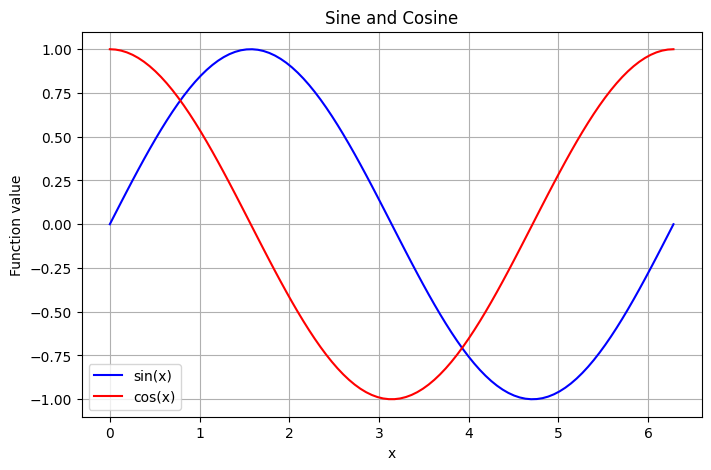

In [ ]:
x = np.linspace(0, 2*np.pi, 100)


y1 = np.sin(x)
y2 = np.cos(x)


plt.figure(figsize=(8, 5))

plt.plot(x, y1, label="sin(x)", color="blue")
plt.plot(x, y2, label="cos(x)", color="red")

plt.title("Sine and Cosine")
plt.xlabel("x")
plt.ylabel("Function value")
plt.legend()
plt.grid()

plt.show()

## Broadcasting with two-dimensional arrays

Suppose we have a matrix.

Each row can represent one observation and each column can represent one feature.

NumPy allows us to perform operations on the entire matrix without explicitly writing nested loops.

This is one of the reasons NumPy is heavily used in machine learning.

In [ ]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])


print("A:")
print(A)

print("\nA + 10:")
print(A + 10)

print("\nA * 2:")
print(A * 2)

A:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

A + 10:
[[11 12 13]
 [14 15 16]
 [17 18 19]]

A * 2:
[[ 2  4  6]
 [ 8 10 12]
 [14 16 18]]


## Matrix operations

A matrix is simply a two-dimensional NumPy array.

Important operations include:

- Addition
- Subtraction
- Element-wise multiplication
- Matrix multiplication
- Transpose

For matrix multiplication we use the @ operator.

A @ B

is different from:

A * B

The * operator performs element-wise multiplication.

The @ operator performs matrix multiplication.

In [ ]:
A = np.array([
    [1, 2],
    [3, 4]
])

B = np.array([
    [5, 6],
    [7, 8]
])

print("A:")
print(A)

print("\nB:")
print(B)

print("\nA + B:")
print(A + B)

print("\nElement-wise A * B:")
print(A * B)

print("\nMatrix multiplication A @ B:")
print(A @ B)

print("\nTranspose of A:")
print(A.T)

A:
[[1 2]
 [3 4]]

B:
[[5 6]
 [7 8]]

A + B:
[[ 6  8]
 [10 12]]

Element-wise A * B:
[[ 5 12]
 [21 32]]

Matrix multiplication A @ B:
[[19 22]
 [43 50]]

Transpose of A:
[[1 3]
 [2 4]]


## Solving linear equations

Suppose we have:

2x + y = 5
x + 3y = 6

This can be written as:

A x = b

where A is the coefficient matrix.

NumPy provides np.linalg.solve() to obtain the solution.

This is different from manually calculating the inverse.

We will use this idea later when discussing linear algebra behind SVD and machine learning.

In [ ]:
A = np.array([
    [2, 1],
    [1, 3]
])

b = np.array([5, 6])

x = np.linalg.solve(A, b)

print("Solution:")
print(x)

print("\nVerification A @ x:")
print(A @ x)

print("\nOriginal b:")
print(b)

Solution:
[1.8 1.4]

Verification A @ x:
[5. 6.]

Original b:
[5 6]


## Eigenvalues and eigenvectors

For a square matrix A, an eigenvector v and its corresponding eigenvalue λ satisfy:

A v = λ v

In NumPy, np.linalg.eig() returns:

- Eigenvalues
- Eigenvectors

We will calculate them and then verify the eigenvalue equation directly.

In [ ]:
A = np.array([
    [4, 1],
    [2, 3]
], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)

print("Matrix A:")
print(A)

print("\nEigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Matrix A:
[[4. 1.]
 [2. 3.]]

Eigenvalues:
[5. 2.]

Eigenvectors:
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]


In [ ]:
i = 0

v = eigenvectors[:, i]
lam = eigenvalues[i]

left_side = A @ v
right_side = lam * v

print("Eigenvalue:", lam)

print("\nA @ v:")
print(left_side)

print("\nλ * v:")
print(right_side)

print("\nAre they approximately equal?")
print(np.allclose(left_side, right_side))

Eigenvalue: 5.0

A @ v:
[3.53553391 3.53553391]

λ * v:
[3.53553391 3.53553391]

Are they approximately equal?
True


#SVD

In [ ]:

A = np.array([
    [1, 2, 3, 4],
    [2, 4, 6, 8],
    [1, 1, 1, 1]
], dtype=float)

print("Shape of A",A.shape)
print(A)

# SVD
U, S, Vt = np.linalg.svd(A)

print("\nU =")
print(U.shape)
print(U)

print("\nSingular values =")
print(S.shape)
print(S)

print("\nVt =")
print(Vt.shape)
print(Vt)

Shape of A (3, 4)
[[1. 2. 3. 4.]
 [2. 4. 6. 8.]
 [1. 1. 1. 1.]]

U =
(3, 3)
[[ 4.42283797e-01  6.62196599e-02  8.94427191e-01]
 [ 8.84567593e-01  1.32439320e-01 -4.47213595e-01]
 [ 1.48071661e-01 -9.88976634e-01 -1.17961196e-15]]

Singular values =
(3,)
[1.23833714e+01 8.07534528e-01 7.09764028e-16]

Vt =
(4, 4)
[[ 0.19053702  0.36911673  0.54769645  0.72627617]
 [-0.81467518 -0.40466386  0.00534747  0.41535879]
 [ 0.5343714  -0.62290599 -0.35730222  0.44583681]
 [-0.12019654  0.55855898 -0.75652833  0.3181659 ]]


In [ ]:
U2 = U[:, :2]
S2 = S[:2]
Vt2 = Vt[:2, :]

# Convert S2 into a 2x2 diagonal matrix
Sigma2 = np.diag(S2)

print("Original U and its shape", U.shape)
print(U)

print("\nU2 and its shape : ",U2.shape)
print(U2)


print("\nOriginal S and its shape", np.diag(S).shape)
print(np.diag(S))

print("\nS2 and its shape : ",Sigma2.shape)
print(Sigma2)




print("\nOriginal Vt and its shape", Vt.shape)
print(Vt)

print("\nVt2 and its shape : ",Vt.shape)
print(Vt2)



Original U and its shape (3, 3)
[[ 4.42283797e-01  6.62196599e-02  8.94427191e-01]
 [ 8.84567593e-01  1.32439320e-01 -4.47213595e-01]
 [ 1.48071661e-01 -9.88976634e-01 -1.17961196e-15]]

U2 and its shape :  (3, 2)
[[ 0.4422838   0.06621966]
 [ 0.88456759  0.13243932]
 [ 0.14807166 -0.98897663]]

Original S and its shape (3, 3)
[[1.23833714e+01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 8.07534528e-01 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 7.09764028e-16]]

S2 and its shape :  (2, 2)
[[12.38337143  0.        ]
 [ 0.          0.80753453]]

Original Vt and its shape (4, 4)
[[ 0.19053702  0.36911673  0.54769645  0.72627617]
 [-0.81467518 -0.40466386  0.00534747  0.41535879]
 [ 0.5343714  -0.62290599 -0.35730222  0.44583681]
 [-0.12019654  0.55855898 -0.75652833  0.3181659 ]]

Vt2 and its shape :  (4, 4)
[[ 0.19053702  0.36911673  0.54769645  0.72627617]
 [-0.81467518 -0.40466386  0.00534747  0.41535879]]


In [ ]:


# Reconstruction
A2 = U2 @ Sigma2 @ Vt2

print("Reconstructed Matrix")
print(A2)

print("\nOriginal Matrix")
print(A)

Reconstructed Matrix
[[1. 2. 3. 4.]
 [2. 4. 6. 8.]
 [1. 1. 1. 1.]]

Original Matrix
[[1. 2. 3. 4.]
 [2. 4. 6. 8.]
 [1. 1. 1. 1.]]


200
Type: <class 'numpy.ndarray'>
Shape: (853, 1280)


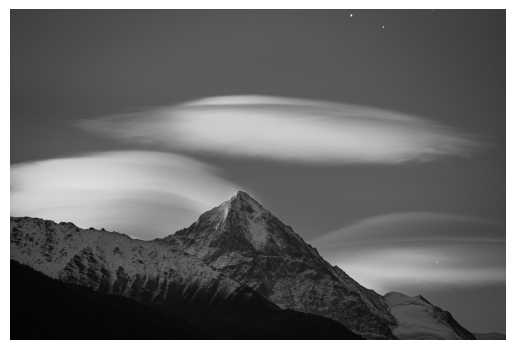

In [ ]:
import requests
from PIL import Image
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt

# Direct image URL
url = "https://yavuzceliker.github.io/sample-images/image-1021.jpg"

# Download image
response = requests.get(url)

print(response.status_code)

# Convert downloaded data to image
image = Image.open(BytesIO(response.content))

# Convert to grayscale
image = image.convert("L")

# Convert to NumPy array
A = np.array(image)

print("Type:", type(A))
print("Shape:", A.shape)

# Display image
plt.imshow(A, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
U, S, Vt = np.linalg.svd(A, full_matrices=False)

print("A  :", A.shape)
print("U  :", U.shape)
print("S  :", S.shape)
print("Vt :", Vt.shape)

A  : (853, 1280)
U  : (853, 853)
S  : (853,)
Vt : (853, 1280)


In [ ]:
np.diag(S)

array([[1.01528023e+05, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 2.61129417e+04, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.83136096e+04, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        3.58937519e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 3.54615207e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 3.48923159e+00]])

Reduced size for 5 singular components is 10670
Reduced size for 10 singular components is 21340
Reduced size for 20 singular components is 42680
Reduced size for 50 singular components is 106700
Reduced size for 100 singular components is 213400


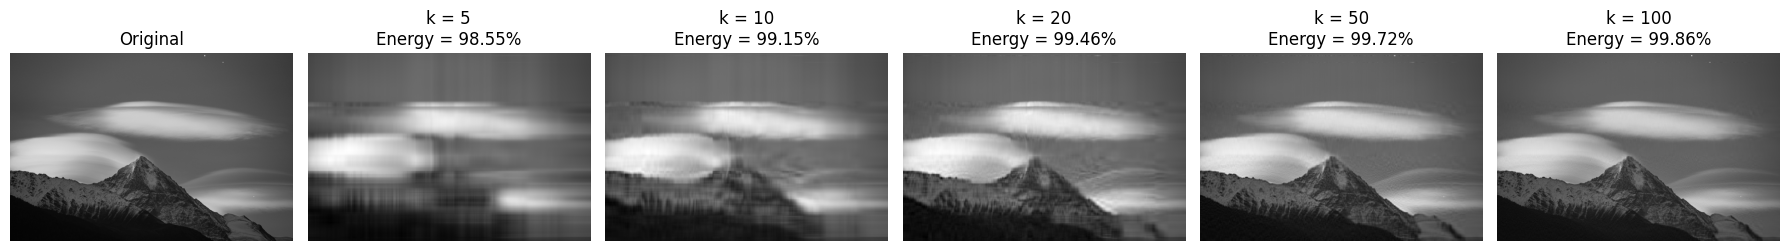

In [ ]:

# --------------------------------------------------
# 3. CALCULATE CUMULATIVE ENERGY
# --------------------------------------------------

energy = np.cumsum(S**2) / np.sum(S**2) * 100


# --------------------------------------------------
# 4. RECONSTRUCT IMAGE USING DIFFERENT k
# --------------------------------------------------

k_values = [5, 10, 20, 50, 100]

fig, axes = plt.subplots(1, 6, figsize=(18, 5))

# Original
axes[0].imshow(A, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

# Reconstructions
for ax, k in zip(axes[1:], k_values):

    A_k = (U[:, :k] @ np.diag(S[:k])) @ Vt[:k, :]
    print(f"Reduced size for {k} singular components is",U[:, :k].size +  S[:k].size + Vt[:k, :].size)

    ax.imshow(A_k, cmap="gray")
    ax.set_title(
        f"k = {k}\n"
        f"Energy = {energy[k-1]:.2f}%"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
m, n = A.shape

original_size = m * n

for k in [5, 10, 20, 50, 100]:

    compressed_size = k * (m + n + 1)

    reduction = 100 * (1 - compressed_size / original_size)

    print(f"k = {k}")
    print(f"  Original numbers     : {original_size}")
    print(f"  SVD representation   : {compressed_size}")
    print(f"  Size reduction       : {reduction:.2f}%")
    print(f"  Information retained : {energy[k-1]:.2f}%")
    print()

k = 5
  Original numbers     : 1091840
  SVD representation   : 10670
  Size reduction       : 99.02%
  Information retained : 98.55%

k = 10
  Original numbers     : 1091840
  SVD representation   : 21340
  Size reduction       : 98.05%
  Information retained : 99.15%

k = 20
  Original numbers     : 1091840
  SVD representation   : 42680
  Size reduction       : 96.09%
  Information retained : 99.46%

k = 50
  Original numbers     : 1091840
  SVD representation   : 106700
  Size reduction       : 90.23%
  Information retained : 99.72%

k = 100
  Original numbers     : 1091840
  SVD representation   : 213400
  Size reduction       : 80.46%
  Information retained : 99.86%



In [ ]:
import requests
from PIL import Image
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt

# Download image
url = "https://yavuzceliker.github.io/sample-images/image-1021.jpg"

response = requests.get(url, timeout=20)
response.raise_for_status()

image = Image.open(BytesIO(response.content)).convert("RGB")

# Convert to NumPy array
A = np.array(image, dtype=float)

print("Image shape:", A.shape)

Image shape: (853, 1280, 3)


In [ ]:
# Separate RGB channels
R = A[:, :, 0]
G = A[:, :, 1]
B = A[:, :, 2]

# SVD
Ur, Sr, Vtr = np.linalg.svd(R, full_matrices=False)
Ug, Sg, Vtg = np.linalg.svd(G, full_matrices=False)
Ub, Sb, Vtb = np.linalg.svd(B, full_matrices=False)

In [ ]:
def reconstruct_color(k):

    Rk = (Ur[:, :k] * Sr[:k]) @ Vtr[:k, :]
    Gk = (Ug[:, :k] * Sg[:k]) @ Vtg[:k, :]
    Bk = (Ub[:, :k] * Sb[:k]) @ Vtb[:k, :]

    # Combine RGB channels
    Ak = np.stack([Rk, Gk, Bk], axis=2)

    return np.clip(Ak, 0, 255).astype(np.uint8)

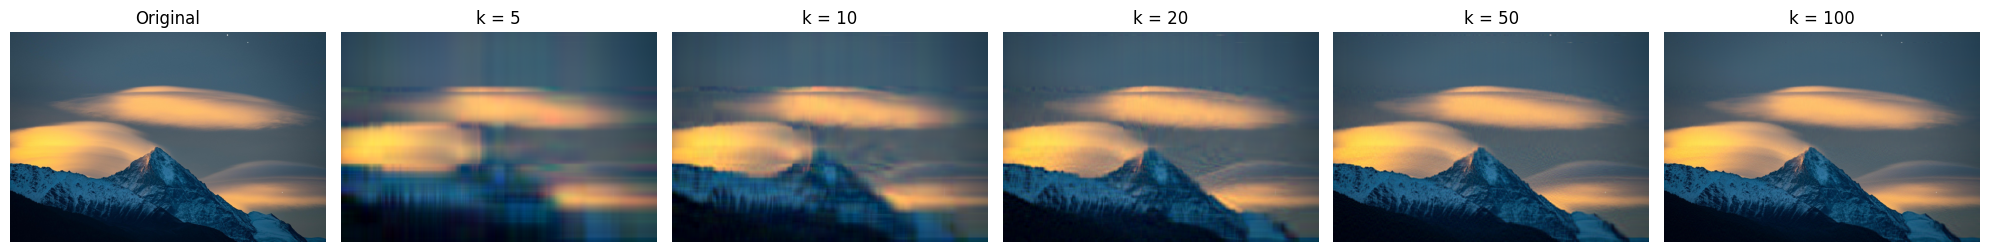

In [ ]:
k_values = [5, 10, 20, 50, 100]

fig, axes = plt.subplots(1, 6, figsize=(20, 5))

axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis("off")

for ax, k in zip(axes[1:], k_values):

    Ak = reconstruct_color(k)

    ax.imshow(Ak)
    ax.set_title(f"k = {k}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
m, n, _ = A.shape

original_size = 3 * m * n

for k in k_values:

    compressed_size = 3 * k * (m + n + 1)

    reduction = 100 * (1 - compressed_size / original_size)

    print(
        f"k={k:3d} | "
        f"Original={original_size:,} | "
        f"SVD={compressed_size:,} | "
        f"Reduction={reduction:.2f}%"
    )

k=  5 | Original=3,275,520 | SVD=32,010 | Reduction=99.02%
k= 10 | Original=3,275,520 | SVD=64,020 | Reduction=98.05%
k= 20 | Original=3,275,520 | SVD=128,040 | Reduction=96.09%
k= 50 | Original=3,275,520 | SVD=320,100 | Reduction=90.23%
k=100 | Original=3,275,520 | SVD=640,200 | Reduction=80.46%


##From Raw Discharge Data to SVD

The NASA B0005 battery contains discharge measurements recorded at unequal time intervals and with different numbers of data points for each discharge cycle. Therefore, the voltage–time data cannot be directly arranged into a conventional 2D matrix for SVD.

In this workflow, we will proceed in two stages:

Extract the voltage and time data from all discharge cycles.
Determine the minimum number of data points among all discharge cycles. This gives us the initial matrix dimension without adding or interpolating any data.
Use these minimum data points to construct a common representation of the discharge curves.
Then apply linear interpolation to map every discharge cycle onto a common time grid.
The resulting voltage matrix can then be used for Singular Value Decomposition (SVD).
Why use the minimum number of data points first?

Each discharge cycle contains a different number of measurements. For example:

Cycle 1  → 197 points
Cycle 2  → 196 points
Cycle 3  → 299 points
...

The minimum number of points provides a natural starting dimension for the data matrix. However, simply taking the first N points from every cycle would not necessarily correspond to the same physical time locations.

Therefore, linear interpolation is subsequently used to place all cycles onto a common time grid.

The final objective is to obtain a matrix of the form:

$$ X = \begin{bmatrix} V_1(t_1) & V_1(t_2) & \cdots & V_1(t_N)\\ V_2(t_1) & V_2(t_2) & \cdots & V_2(t_N)\\ \vdots & \vdots & \ddots & \vdots\\ V_M(t_1) & V_M(t_2) & \cdots & V_M(t_N) \end{bmatrix} $$

where:

\(M\) = number of discharge cycles
\(N\) = minimum number of data points selected as the common dimension
\(V_i(t)\) = voltage of discharge cycle \(i\)

This matrix will subsequently be decomposed using:

$$ X = U\Sigma V^T $$

to identify the dominant patterns in the battery discharge curves.





#Importing Data


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

from pathlib import Path

data_folder = Path("/content/drive/MyDrive")

print("Data folder:")
print(data_folder)


try:
  mat_file = list(data_folder.rglob('B0005.mat'))[0]

  print("MAT file:")
  print(mat_file)

  print("Does the file exist?")
  print(mat_file.exists())

except FileNotFoundError:
  print("No file found.")
except IndexError:
  print("Filepath Not existing")

Mounted at /content/drive
Data folder:
/content/drive/MyDrive
MAT file:
/content/drive/MyDrive/BML_SVD/5. Battery Data Set/1. BatteryAgingARC-FY08Q4/B0005.mat
Does the file exist?
True


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

data = loadmat(mat_file)


In [ ]:
B0005 = data["B0005"].ravel()[0]
cycle = B0005["cycle"].ravel()

# Mask: select only discharge cycles
mask = np.array([
    str(cycle[i]["type"].ravel()[0]) == "discharge"
    for i in range(len(cycle))
])

discharge_cycles = cycle[mask]

In [ ]:
#Code to demonstrate ravel function of numpy
import numpy as np

A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

print(A)
print(f"Shape of A {A.shape}")

B = A.ravel()

print(B)
print(f"Shape of A after ravel {B.shape}")

[[1 2 3]
 [4 5 6]]
Shape of A (2, 3)
[1 2 3 4 5 6]
Shape of A after ravel (6,)


In [ ]:

# Extract voltage and time
voltage_data = []
time_data = []

for discharge_cycle in discharge_cycles:

    data_structure = discharge_cycle["data"].ravel()[0]

    voltage = data_structure["Voltage_measured"].ravel()
    time = data_structure["Time"].ravel()

    voltage_data.append(voltage)
    time_data.append(time)

# Convert to NumPy arrays
voltage_data = np.array(voltage_data, dtype=object)
time_data = np.array(time_data, dtype=object)

print("Voltage array shape:", voltage_data.shape)
print("Time array shape:", time_data.shape)
print("Voltage data type:", voltage_data.dtype)

Voltage array shape: (168,)
Time array shape: (168,)
Voltage data type: object


In [ ]:
print("Number of cycles:", len(discharge_cycles))

for i in range(min(10, len(discharge_cycles))):

    cycle_data = discharge_cycles[i]["data"]

    voltage = np.asarray(
        cycle_data["Voltage_measured"].ravel()[0],
        dtype=float
    ).ravel()

    print(f"Cycle {i}: {len(voltage)} voltage points")

Number of cycles: 168
Cycle 0: 197 voltage points
Cycle 1: 196 voltage points
Cycle 2: 195 voltage points
Cycle 3: 194 voltage points
Cycle 4: 194 voltage points
Cycle 5: 195 voltage points
Cycle 6: 195 voltage points
Cycle 7: 191 voltage points
Cycle 8: 190 voltage points
Cycle 9: 190 voltage points


In [ ]:
print(type(voltage_data[0]))
print(voltage_data[0].shape)

print(type(time_data[0]))
print(time_data[0].shape)

<class 'numpy.ndarray'>
(197,)
<class 'numpy.ndarray'>
(197,)


In [ ]:
print(voltage_data[0])

[4.19149181 4.19074907 3.97487091 3.95171671 3.93435249 3.92005844
 3.90790351 3.89703572 3.88747658 3.87895859 3.87101598 3.86347968
 3.85666051 3.85001358 3.84384191 3.83768798 3.83193825 3.82641444
 3.82109573 3.81589666 3.81069682 3.80583738 3.80112163 3.79629313
 3.79144891 3.78662469 3.78206292 3.7771754  3.77240629 3.76793746
 3.7632293  3.75851149 3.75421321 3.7496292  3.74516886 3.74100501
 3.73669983 3.73248271 3.72835255 3.72453324 3.72065103 3.71640901
 3.71279184 3.70842761 3.70479177 3.70068258 3.69675771 3.69303933
 3.6891768  3.68521448 3.68149374 3.67779221 3.67406181 3.67030176
 3.66673391 3.66299805 3.65966439 3.65589414 3.65232651 3.64876348
 3.64554686 3.64207625 3.63846406 3.63507607 3.63166482 3.62857854
 3.6250126  3.62158223 3.61846125 3.61506725 3.61188181 3.60857868
 3.60553494 3.6021859  3.59885715 3.59576709 3.59301666 3.58971009
 3.5866522  3.58344204 3.58048534 3.57725048 3.57436883 3.57128513
 3.56872067 3.56555467 3.56259541 3.55978447 3.55689375 3.5539

In [ ]:
print(time_data[0])

[   0.      16.781   35.703   53.781   71.922   90.094  108.281  126.453
  144.641  162.844  181.016  199.219  217.391  235.594  253.75   271.984
  290.141  308.359  326.5    344.75   362.906  381.047  399.187  417.281
  435.484  453.672  471.812  490.203  508.344  526.625  544.922  563.125
  581.406  599.656  617.875  636.047  654.422  672.594  690.812  708.937
  727.266  745.578  763.797  782.109  800.484  818.797  837.016  855.25
  873.578  891.812  910.141  928.391  946.719  965.047  983.391 1001.766
 1020.172 1038.594 1056.922 1075.203 1093.687 1112.    1130.328 1148.75
 1167.125 1185.641 1203.984 1222.406 1240.797 1259.156 1277.547 1295.906
 1314.297 1332.687 1351.203 1369.687 1388.125 1406.578 1425.062 1443.609
 1462.047 1480.547 1499.031 1517.672 1536.109 1554.781 1573.281 1591.859
 1610.406 1628.953 1647.562 1666.062 1684.656 1703.219 1721.891 1740.437
 1759.016 1777.641 1796.328 1815.047 1833.75  1852.391 1871.078 1889.844
 1908.578 1927.281 1946.031 1964.891 1983.703 2002.48

Total Cycles are: 168


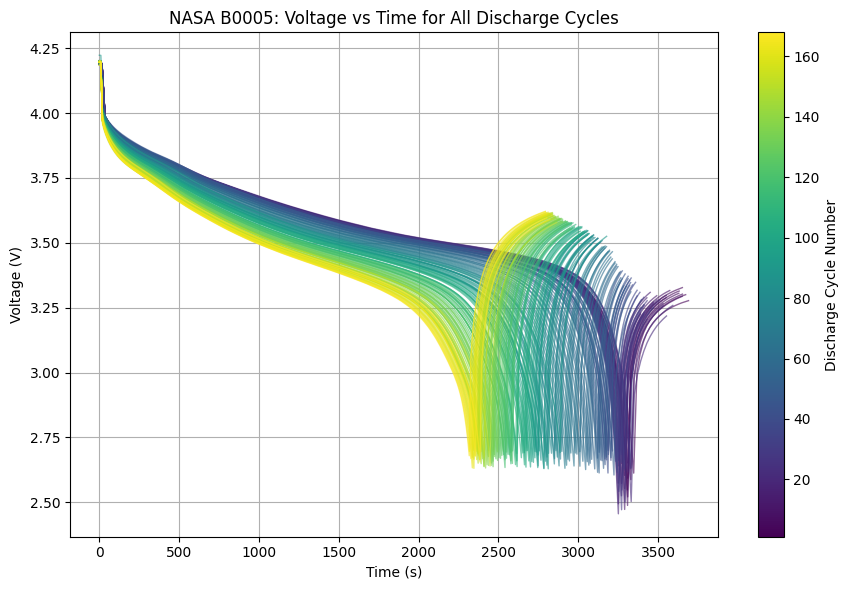

In [ ]:
import matplotlib.cm as cm

# 1. Initialize the figure and axis
plt.figure(figsize=(9, 6))
ax = plt.gca()

total_cycles = len(voltage_data)

print("Total Cycles are:", total_cycles)

# 2. Plot all discharge cycles
for i in range(total_cycles):

    voltage = voltage_data[i]
    time = time_data[i]

    # 3. Color according to cycle progression
    color_ratio = i / (total_cycles - 1) if total_cycles > 1 else 0.0
    cycle_color = cm.viridis(color_ratio)

    # 4. Plot
    plt.plot(
        time,
        voltage,
        color=cycle_color,
        alpha=0.6,
        linewidth=1
    )

# 5. Labels and formatting
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("NASA B0005: Voltage vs Time for All Discharge Cycles")
plt.grid(True)

# 6. Colorbar
sm = plt.cm.ScalarMappable(
    cmap=cm.viridis,
    norm=plt.Normalize(vmin=1, vmax=total_cycles)
)

sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Discharge Cycle Number")

plt.tight_layout()
plt.show()

In [ ]:
# ==================================================
# 1. Find minimum dimension
# ==================================================

min_dimension = min(len(v) for v in voltage_data)

print("Minimum dimension:", min_dimension)


# ==================================================
# 2. Take first n points from every cycle
# ==================================================

n = min_dimension

voltage_matrix = np.array([
    voltage_data[i][:n]
    for i in range(len(voltage_data))
])

time_matrix = np.array([
    time_data[i][:n]
    for i in range(len(time_data))
])

print("Voltage matrix shape:", voltage_matrix.shape)
print("Time matrix shape:", time_matrix.shape)




Minimum dimension: 179
Voltage matrix shape: (168, 179)
Time matrix shape: (168, 179)


In [ ]:
# ==================================================
# 3. SVD
# ==================================================

U, S, VT = np.linalg.svd(
    voltage_matrix,
    full_matrices=False
)


# Energy associated with each singular value

energy = S**2


# Fraction of total energy

explained_energy = (
    energy / np.sum(energy)
)


# Cumulative energy

cumulative_energy = np.cumsum(
    explained_energy
)


print("\nSVD Energy:")
for i in range(10):
    print(
        f"Component {i+1}: "
        f"{explained_energy[i]*100:.4f}%  "
        f"Cumulative: {cumulative_energy[i]*100:.4f}%"
    )


SVD Energy:
Component 1: 99.9841%  Cumulative: 99.9841%
Component 2: 0.0133%  Cumulative: 99.9974%
Component 3: 0.0011%  Cumulative: 99.9985%
Component 4: 0.0008%  Cumulative: 99.9994%
Component 5: 0.0003%  Cumulative: 99.9996%
Component 6: 0.0002%  Cumulative: 99.9998%
Component 7: 0.0001%  Cumulative: 99.9999%
Component 8: 0.0001%  Cumulative: 100.0000%
Component 9: 0.0000%  Cumulative: 100.0000%
Component 10: 0.0000%  Cumulative: 100.0000%


In [ ]:
# ==================================================
# 4. Reconstruct voltage data using k components
# ==================================================

k = 3

voltage_reconstructed = (
    U[:, :k]
    @ np.diag(S[:k])
    @ VT[:k, :]
)

print("Original shape:", voltage_matrix.shape)
print("Reconstructed shape:", voltage_reconstructed.shape)

Original shape: (168, 179)
Reconstructed shape: (168, 179)


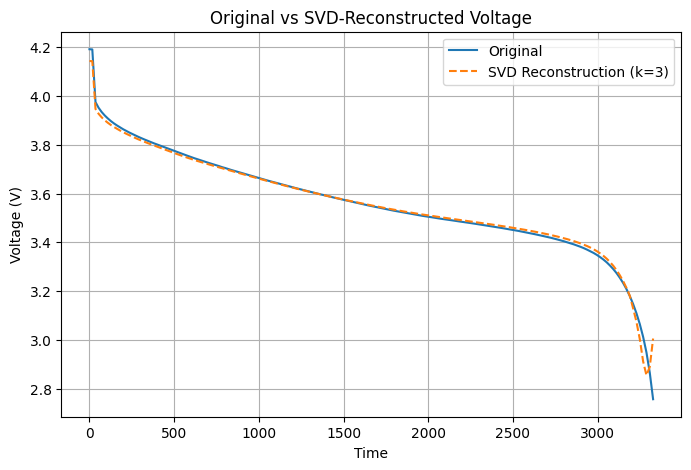

In [ ]:
# ==================================================
# 5. Plot Original vs SVD Reconstruction
# ==================================================

cycle = 0

plt.figure(figsize=(8, 5))

plt.plot(
    time_matrix[cycle],
    voltage_matrix[cycle],
    label="Original"
)

plt.plot(
    time_matrix[cycle],
    voltage_reconstructed[cycle],
    "--",
    label=f"SVD Reconstruction (k={k})"
)

plt.xlabel("Time")
plt.ylabel("Voltage (V)")
plt.title("Original vs SVD-Reconstructed Voltage")

plt.legend()
plt.grid(True)

plt.show()

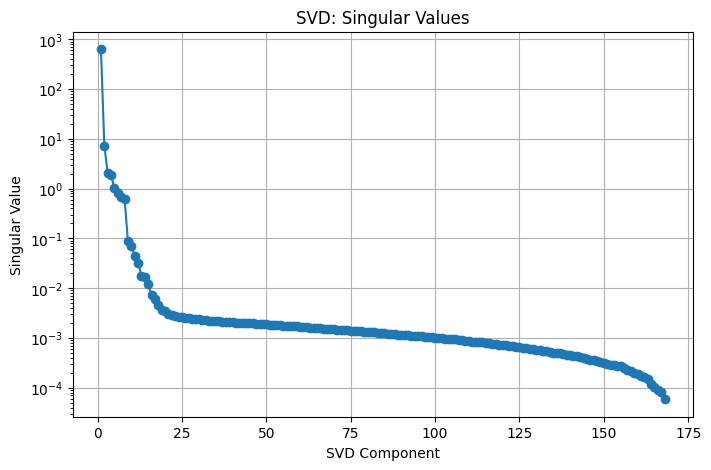

In [ ]:

#Plot SVD Singular values

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(S) + 1),
    S,
    marker="o"
)

plt.xlabel("SVD Component")
plt.ylabel("Singular Value")
plt.title("SVD: Singular Values")

plt.yscale("log")

plt.grid(True)
plt.show()



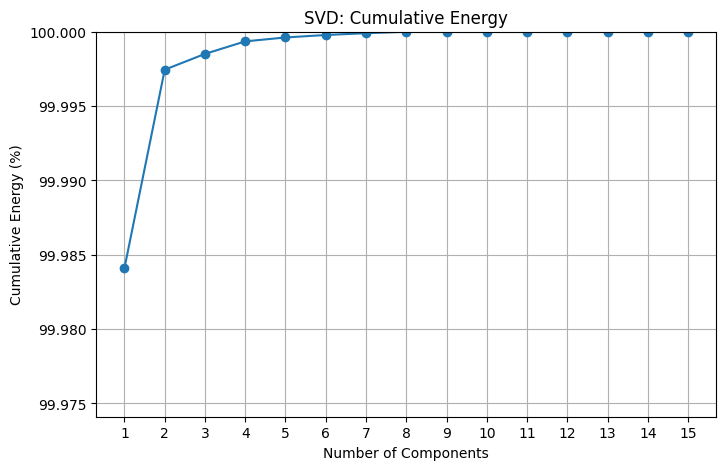

In [ ]:

# ==================================================
# Plot SVD Cumulative Energy
# ==================================================

n_show = 15

energy_percent = cumulative_energy[:n_show] * 100

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, n_show + 1),
    energy_percent,
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Energy (%)")
plt.title("SVD: Cumulative Energy")

# Start slightly below the first value
plt.ylim(
    energy_percent[0] - 0.01,
    100
)

plt.xticks(
    range(1, n_show + 1)
)

plt.grid(True)

plt.show()


In [ ]:
# ==================================================
# Extract Capacity
# ==================================================

capacity = np.array([
    discharge_cycle["data"].ravel()[0]["Capacity"].ravel()[0]
    for discharge_cycle in discharge_cycles
])

print("Capacity shape:", capacity.shape)

Capacity shape: (168,)


In [ ]:
# ==================================================
# SVD already performed
# U, S, VT are already available
# ==================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


# ==================================================
# 1. Train-Test Split
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    voltage_matrix,
    capacity,
    test_size=0.2,
    random_state=42
)


# ==================================================
# 2. SVD on Training Data
# ==================================================

U_train, S_train, VT_train = np.linalg.svd(
    X_train,
    full_matrices=False
)


# ==================================================
# 3. Select number of dimensions
# ==================================================

k = 3


# ==================================================
# 4. Training data → Low-dimensional representation
# ==================================================

X_train_low = (
    U_train[:, :k] * S_train[:k]
)


# ==================================================
# 5. Test data → Same low-dimensional space
# ==================================================

X_test_low = (
    X_test @ VT_train[:k, :].T
)


print("Training low-dimensional shape:",
      X_train_low.shape)

print("Testing low-dimensional shape:",
      X_test_low.shape)


# ==================================================
# 6. Linear Regression
# ==================================================

model = LinearRegression()

model.fit(
    X_train_low,
    y_train
)


# ==================================================
# 7. Predict Capacity
# ==================================================

y_train_pred = model.predict(X_train_low)

y_test_pred = model.predict(X_test_low)


# ==================================================
# 8. Evaluation
# ==================================================

print("\nTraining:")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R² :", r2_score(y_train, y_train_pred))

print("\nTesting:")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R² :", r2_score(y_test, y_test_pred))

Training low-dimensional shape: (134, 3)
Testing low-dimensional shape: (34, 3)

Training:
MAE: 0.018980877776358516
R² : 0.9794767607038847

Testing:
MAE: 0.0301937230067188
R² : 0.915828402700327


#PCA

In [ ]:
from sklearn.decomposition import PCA

# ==================================================
# 6. PCA using sklearn
# ==================================================

# Create PCA model
pca = PCA()

# Fit PCA to voltage data
pca.fit(voltage_matrix)


# Explained variance ratio
explained_variance = pca.explained_variance_ratio_


# Cumulative explained variance
cumulative_variance = np.cumsum(
    explained_variance
)



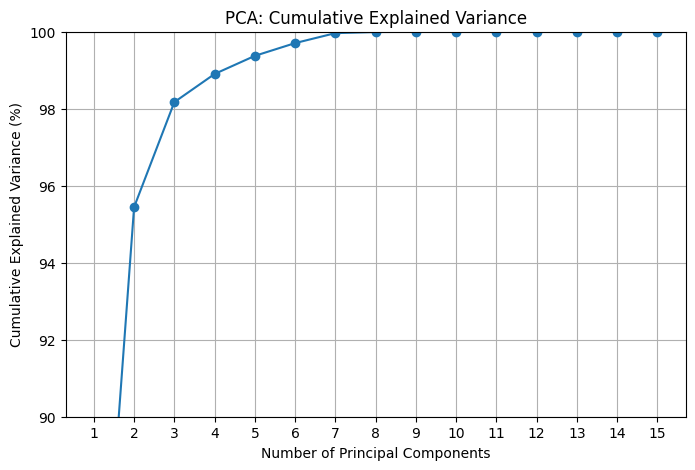

In [ ]:
# ==================================================
# 7. Plot PCA Cumulative Explained Variance
# ==================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, n_show + 1),
    cumulative_variance[:n_show] * 100,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA: Cumulative Explained Variance")

plt.ylim(90, 100)

plt.xticks(
    range(1, n_show + 1)
)

plt.grid(True)

plt.show()

## A small visualization of a linear combination

Suppose:

y = a cos(x) + b sin(x)

Instead of calculating each point using a loop, NumPy performs the calculation for the entire array x.

This is another example of vectorization.

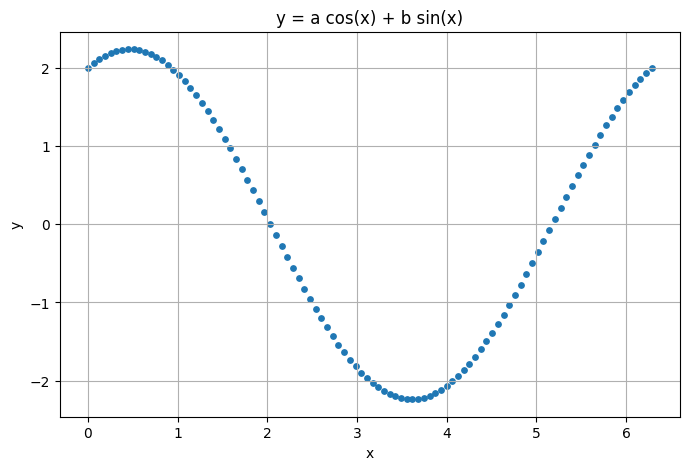

In [ ]:
x = np.linspace(0, 2*np.pi, 100)

a = 2
b = 1

y = a*np.cos(x) + b*np.sin(x)

plt.figure(figsize=(8, 5))

plt.scatter(x, y, s=15)

plt.title("y = a cos(x) + b sin(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()

plt.show()

## Summary of NumPy concepts

We have now used:

1. np.array()
2. shape
3. ndim
4. size
5. Vectorized arithmetic
6. Broadcasting
7. np.linspace()
8. Matrix operations
9. Matrix multiplication using @
10. Transpose
11. np.linalg.solve()
12. np.linalg.eig()
13. Verification of eigenvalues/eigenvectors
14. Matplotlib plotting

These concepts will appear repeatedly in the battery-data analysis.

**MODULE 3 — LOAD DATA FROM GOOGLE DRIVE**

# Module 3 — Loading the Battery Dataset

We will now move from simple NumPy examples to the actual battery dataset.

The dataset is stored in Google Drive.

We will mount Google Drive in Google Colab and then use pathlib.Path to construct the file path.

Using Path is preferable to manually joining strings because it provides a clean way to work with file paths.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

data_folder = Path("/content/drive/MyDrive")

print("Data folder:")
print(data_folder)

Data folder:
/content/drive/MyDrive


In [ ]:

try:
  mat_file = list(data_folder.rglob('B0005.mat'))[0]

  print("MAT file:")
  print(mat_file)

  print("Does the file exist?")
  print(mat_file.exists())

except FileNotFoundError:
  print("No file found.")
except IndexError:
  print("Filepath Not existing")

MAT file:
/content/drive/MyDrive/BML_SVD/5. Battery Data Set/1. BatteryAgingARC-FY08Q4/B0005.mat
Does the file exist?
True


#Data Hierarchy Display

In [ ]:
import numpy as np
import plotly.graph_objects as go
from scipy.io import loadmat

data = loadmat(mat_file)


# ============================================================
# 1. Unravel B0005 and cycle
# ============================================================

B0005 = data["B0005"].ravel()[0]

cycle = B0005["cycle"].ravel()

print("Total cycles:", len(cycle))


# ============================================================
# 2. Find one real example of each cycle type
# ============================================================

examples = {}

for i in range(len(cycle)):

    current_cycle = cycle[i]

    cycle_type = current_cycle["type"].ravel()[0]

    cycle_type = str(cycle_type)

    if cycle_type not in examples:

        examples[cycle_type] = (
            i + 1,
            current_cycle
        )


# ============================================================
# 3. Create hierarchy
# ============================================================

labels = []
parents = []
ids = []
hover_text = []
colors = []


# ============================================================
# 4. Color definitions
# ============================================================

# Cycle types
charge_color = "#59A14F"
discharge_color = "#E15759"
impedance_color = "#F28E2B"

# Data fields
measurement_colors = {

    "Voltage_measured": "#4E79A7",
    "Current_measured": "#76B7B2",
    "Temperature_measured": "#F28E2B",

    "Current_charge": "#59A14F",
    "Voltage_charge": "#B07AA1",

    "Current_load": "#9C755F",
    "Voltage_load": "#EDC949",

    "Time": "#AF7AA1",
    "Capacity": "#E15759",

    "Sense_current": "#4E79A7",
    "Battery_current": "#76B7B2",
    "Current_ratio": "#59A14F",
    "Battery_impedance": "#F28E2B",
    "Rectified_Impedance": "#B07AA1",
    "Re": "#E15759",
    "Rct": "#9C755F"
}


# ============================================================
# 5. ROOT
# ============================================================

ids.append("B0005")

labels.append("B0005")

parents.append("")

hover_text.append(
    "<b>B0005</b><br>"
    "NASA Battery Dataset<br>"
    "616 total cycles"
)

colors.append("#2F5597")


# ============================================================
# 6. CYCLE
# ============================================================

ids.append("cycle")

labels.append("cycle")

parents.append("B0005")

hover_text.append(
    "<b>cycle</b><br>"
    f"Number of cycles: {len(cycle)}<br>"
    "Structured array after ravel(): (616,)"
)

colors.append("#7F7F7F")


# ============================================================
# 7. Add three cycle types
# ============================================================

for cycle_type, (cycle_number, example) in examples.items():

    type_id = f"type_{cycle_type}"

    # --------------------------------------------------------
    # Cycle type
    # --------------------------------------------------------

    ids.append(type_id)

    labels.append(
        cycle_type.capitalize()
    )

    parents.append("cycle")

    hover_text.append(
        f"<b>{cycle_type.capitalize()}</b><br>"
        f"Example cycle: {cycle_number}"
    )

    if cycle_type == "charge":
        colors.append(charge_color)

    elif cycle_type == "discharge":
        colors.append(discharge_color)

    else:
        colors.append(impedance_color)


    # --------------------------------------------------------
    # Example cycle
    # --------------------------------------------------------

    cycle_id = f"cycle_{cycle_number}"

    ids.append(cycle_id)

    labels.append(
        f"Cycle {cycle_number}"
    )

    parents.append(type_id)

    hover_text.append(
        f"<b>Cycle {cycle_number}</b><br>"
        f"Type: {cycle_type}"
    )

    colors.append(
        "#A0A0A0"
    )


    # ========================================================
    # 8. Fields directly inside cycle
    # ========================================================

    for field in example.dtype.names:

        # ----------------------------------------------------
        # Skip data for the moment
        # ----------------------------------------------------

        if field == "data":
            continue

        value = example[field]

        field_id = (
            f"{cycle_number}_{field}"
        )

        ids.append(field_id)

        labels.append(field)

        parents.append(cycle_id)

        hover_text.append(
            f"<b>{field}</b><br>"
            f"dtype: {value.dtype}<br>"
            f"shape: {value.shape}<br>"
            f"dimensions: {value.ndim}"
        )

        colors.append(
            measurement_colors.get(
                field,
                "#BAB0AC"
            )
        )


    # ========================================================
    # 9. DATA
    # ========================================================

    data_id = f"data_{cycle_number}"

    ids.append(data_id)

    labels.append("data")

    parents.append(cycle_id)

    hover_text.append(
        "<b>data</b><br>"
        "Nested measurement structure"
    )

    colors.append("#6F6F6F")


    # ========================================================
    # 10. Fields inside DATA
    # ========================================================

    nested_data = example["data"].ravel()[0]

    for field in nested_data.dtype.names:

        value = nested_data[field]

        field_id = (
            f"{cycle_number}_data_{field}"
        )

        ids.append(field_id)

        labels.append(field)

        parents.append(data_id)

        hover_text.append(
            f"<b>{field}</b><br>"
            f"dtype: {value.dtype}<br>"
            f"shape: {value.shape}<br>"
            f"dimensions: {value.ndim}"
        )

        colors.append(
            measurement_colors.get(
                field,
                "#BAB0AC"
            )
        )


# ============================================================
# 11. Create interactive Treemap
# ============================================================

fig = go.Figure(

    go.Treemap(

        ids=ids,

        labels=labels,

        parents=parents,

        marker=dict(
            colors=colors,
            line=dict(
                width=2
            )
        ),

        hovertext=hover_text,

        hovertemplate=(
            "%{hovertext}"
            "<extra></extra>"
        ),

        branchvalues="total",

        tiling=dict(
            pad=8
        )
    )
)


# ============================================================
# 12. Add legend
# ============================================================

legend = [

    ("Voltage measured", "#4E79A7"),
    ("Current measured", "#76B7B2"),
    ("Temperature measured", "#F28E2B"),
    ("Charge variables", "#59A14F"),
    ("Discharge variables", "#E15759"),
    ("Impedance variables", "#B07AA1"),
    ("Time", "#AF7AA1"),
    ("Capacity", "#E15759"),
    ("Other", "#BAB0AC")
]


for name, color in legend:

    fig.add_trace(

        go.Scatter(

            x=[None],
            y=[None],

            mode="markers",

            marker=dict(
                size=12,
                color=color
            ),

            name=name,

            showlegend=True
        )
    )


# ============================================================
# 13. Layout
# ============================================================

fig.update_layout(

    title=dict(
        text=(
            "NASA B0005 — Interactive Data Structure"
        ),
        x=0.5
    ),

    height=850,

    margin=dict(
        t=80,
        l=10,
        r=220,
        b=10
    ),

    legend=dict(
        title="Data / Variable Type",
        x=1.02,
        y=1
    )
)


# ============================================================
# 14. Display
# ============================================================

fig.show()

Total cycles: 616


**MODULE 4 — LOAD AND UNRAVEL THE MATLAB DATA**

# Module 4 — Loading and Understanding the MATLAB File

The battery data is stored in a MATLAB .mat file.

We will use scipy.io.loadmat() to load it.

For teaching purposes, we will initially use loadmat() with its default settings.

The most important lesson here is:

DO NOT assume that the data is already a simple NumPy array.

MATLAB files can contain nested structures.

Therefore, after loading the file, we first inspect its structure.

In [ ]:
from scipy.io import loadmat

data = loadmat(mat_file)

print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['__header__', '__version__', '__globals__', 'B0005'])


The result is usually a Python dictionary.

The dictionary contains MATLAB variables.

Some entries such as __header__, __version__ and __globals__ are metadata.

The actual battery data is stored in one of the remaining entries.

In [ ]:
#The getattr method

class User:
    def __init__(self, name, role):
        self.name = name
        self.role = role

me = User("Alice", "Admin")

# These two lines do the exact same thing:
print(me.name)                # Output: Alice
print(getattr(me, "name"))    # Output: Alice


Alice
Alice


In [ ]:
for key in data:
    print(key, type(data[key]), getattr(data[key], "shape", "N/A"))

__header__ <class 'bytes'> N/A
__version__ <class 'str'> N/A
__globals__ <class 'list'> N/A
B0005 <class 'numpy.ndarray'> (1, 1)


In [ ]:
data0 = data["B0005"]

print("Type:", type(data0))
print("Shape:", data0.shape)
print("Dtype:", data0.dtype)

Type: <class 'numpy.ndarray'>
Shape: (1, 1)
Dtype: [('cycle', 'O')]


In [ ]:
getattr(data0,'dtype')

dtype([('cycle', 'O')])

The MATLAB structure is nested.

We therefore inspect it level by level rather than immediately trying to access:

data0["Voltage_measured"]

because data0 may not itself be the record containing Voltage_measured.

We first identify the fields available at each level.

In [ ]:
print("Field names:")
print(data0.dtype.names)

Field names:
('cycle',)


In [ ]:
data1 = data0.ravel()[0]

print("Type:", type(data1))
print("Shape:", getattr(data1, "shape", "N/A"))

print("Fields:")
print(data1.dtype.names)

Type: <class 'numpy.void'>
Shape: ()
Fields:
('cycle',)


In [ ]:
print("Cycle information:")

for name in data1.dtype.names:
    value = data1[name]

    print(
        name,
        "→",
        type(value),
        "shape:",
        getattr(value, "shape", "N/A")
    )

Cycle information:
cycle → <class 'numpy.ndarray'> shape: (1, 616)


**MODULE 5 — EXTRACT DISCHARGE DATA**

# Module 5 — Extracting Discharge Cycles

The battery experiment contains different types of cycles.

We are interested in discharge cycles because the discharge curve contains information about the battery state.

We will therefore identify cycles whose type is "discharge".

Because the MATLAB structure contains nested arrays, we inspect each cycle carefully.

A key lesson from this dataset is:

The object may look like a NumPy array, but its individual fields can still contain nested object arrays.

Therefore, we use ravel() and inspect the structure before converting numerical fields to float arrays.

In [ ]:
cycles = data1["cycle"]

print("Cycle container type:", type(cycles))
print("Cycle container shape:", cycles.shape)

Cycle container type: <class 'numpy.ndarray'>
Cycle container shape: (1, 616)


In [ ]:
cycle0 = cycles.ravel()[0]

print("cycle0 type:", type(cycle0))
print("cycle0 shape:", getattr(cycle0, "shape", "N/A"))
print("cycle0 fields:", cycle0.dtype.names)

cycle0 type: <class 'numpy.void'>
cycle0 shape: ()
cycle0 fields: ('type', 'ambient_temperature', 'time', 'data')


In [ ]:
discharge_cycles = []

for i in range(cycles.size):

    cycle = cycles.ravel()[i]

    #Each cycle is a structured record that is numpy.void objects

    cycle_type = cycle["type"]

    if isinstance(cycle_type, np.ndarray):
        cycle_type = cycle_type.ravel()[0]

    if isinstance(cycle_type, bytes):
        cycle_type = cycle_type.decode()

    if cycle_type == "discharge":
        discharge_cycles.append(cycle)

print("Number of discharge cycles:", len(discharge_cycles))

Number of discharge cycles: 168


We now have a list containing only the discharge cycles.

Before extracting voltage and time, we inspect the first discharge cycle.

This is important because Voltage_measured and Time may themselves be nested object arrays.

In [ ]:
cycle = discharge_cycles[0]

print("Cycle type:", type(cycle))
print("Cycle fields:", cycle.dtype.names)

cycle_data = cycle["data"]

print("\nData type:", type(cycle_data))
print("Data shape:", cycle_data.shape)
print("Data dtype:", cycle_data.dtype)

Cycle type: <class 'numpy.void'>
Cycle fields: ('type', 'ambient_temperature', 'time', 'data')

Data type: <class 'numpy.ndarray'>
Data shape: (1, 1)
Data dtype: [('Voltage_measured', 'O'), ('Current_measured', 'O'), ('Temperature_measured', 'O'), ('Current_load', 'O'), ('Voltage_load', 'O'), ('Time', 'O'), ('Capacity', 'O')]


In [ ]:
print("Data fields:")
print(cycle_data.dtype.names)

Data fields:
('Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time', 'Capacity')


In [ ]:
voltage_field = cycle_data["Voltage_measured"]

print("Voltage field type:", type(voltage_field))
print("Voltage field shape:", voltage_field.shape)
print("Voltage field dtype:", voltage_field.dtype)

Voltage field type: <class 'numpy.ndarray'>
Voltage field shape: (1, 1)
Voltage field dtype: object


In [ ]:
voltage_data = voltage_field.ravel()[0]

print("Voltage data type:", type(voltage_data))
print("Voltage data shape:", voltage_data.shape)
print("Voltage data dtype:", voltage_data.dtype)

Voltage data type: <class 'numpy.ndarray'>
Voltage data shape: (1, 197)
Voltage data dtype: float64


In [ ]:
voltage = np.asarray(voltage_data, dtype=float).ravel()

time_field = cycle_data["Time"]
time_data = time_field.ravel()[0]

time = np.asarray(time_data, dtype=float).ravel()

print("Voltage shape:", voltage.shape)
print("Time shape:", time.shape)
print("Voltage length:", len(voltage))
print("Time length:", len(time))

Voltage shape: (197,)
Time shape: (197,)
Voltage length: 197
Time length: 197


In [ ]:
print("Number of discharge cycles:", len(discharge_cycles))

for i in range(min(5, len(discharge_cycles))):

    cycle = discharge_cycles[i]
    cycle_data = cycle["data"]

    voltage = np.asarray(
        cycle_data["Voltage_measured"].ravel()[0],
        dtype=float
    ).ravel()

    time = np.asarray(
        cycle_data["Time"].ravel()[0],
        dtype=float
    ).ravel()

    print(
        "Cycle", i,
        "→ Voltage:", len(voltage),
        "points | Time:", len(time),
        "points"
    )

Number of discharge cycles: 168
Cycle 0 → Voltage: 197 points | Time: 197 points
Cycle 1 → Voltage: 196 points | Time: 196 points
Cycle 2 → Voltage: 195 points | Time: 195 points
Cycle 3 → Voltage: 194 points | Time: 194 points
Cycle 4 → Voltage: 194 points | Time: 194 points


**MODULE 6 — PLOT DISCHARGE DATA**

# Module 6 — Visualizing the Discharge Curves

Before performing any mathematical transformation, we should look at the data.

We will plot voltage against time for several discharge cycles.

This lets us see:

- The shape of the discharge curve
- Differences between cycles
- Differences in the number of measurements
- Regions where the voltage changes rapidly
- Regions where the voltage changes slowly

Visualization is an important part of understanding the data before applying machine learning.

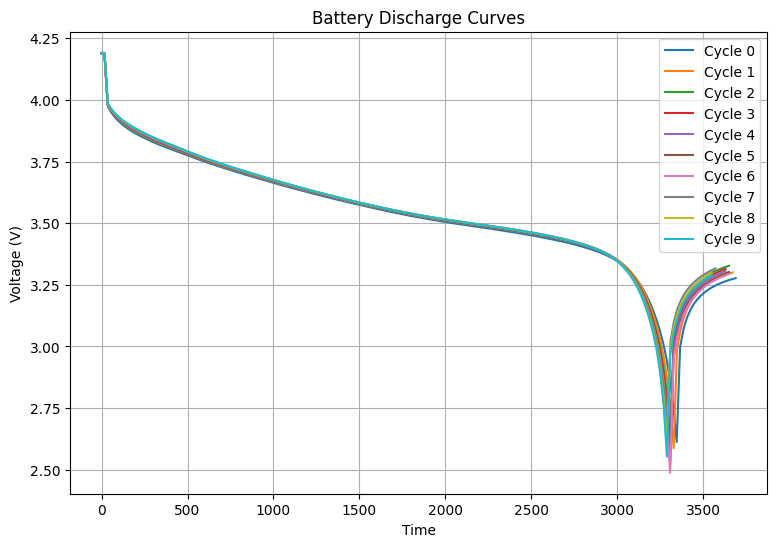

In [ ]:
plt.figure(figsize=(9, 6))

for i in range(min(10, len(discharge_cycles))):

    cycle_data = discharge_cycles[i]["data"]

    voltage = np.asarray(
        cycle_data["Voltage_measured"].ravel()[0],
        dtype=float
    ).ravel()

    time = np.asarray(
        cycle_data["Time"].ravel()[0],
        dtype=float
    ).ravel()

    plt.plot(time, voltage, label=f"Cycle {i}")

plt.xlabel("Time")
plt.ylabel("Voltage (V)")
plt.title("Battery Discharge Curves")
plt.legend()
plt.grid()

plt.show()

Visualize all the discharge curves

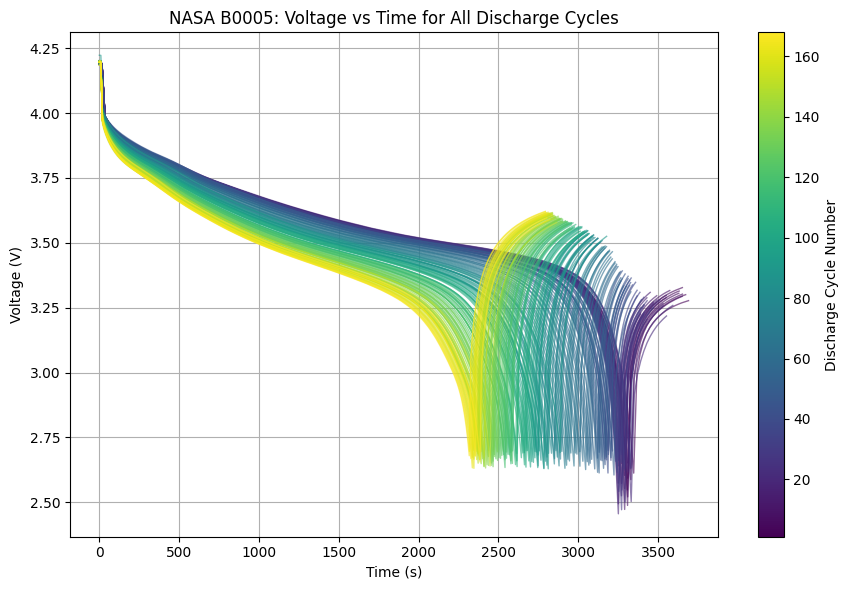

In [ ]:
import matplotlib.cm as cm

# 1. Initialize the figure and axis
plt.figure(figsize=(9, 6))
ax = plt.gca()

total_cycles = len(discharge_cycles)

# 2. Plot all discharge cycles
for i in range(total_cycles):

    cycle_data = discharge_cycles[i]["data"]

    # Extract voltage and time
    voltage = np.asarray(
        cycle_data["Voltage_measured"].ravel()[0],
        dtype=float
    ).ravel()

    time = np.asarray(
        cycle_data["Time"].ravel()[0],
        dtype=float
    ).ravel()

    # 3. Color according to cycle progression
    color_ratio = i / (total_cycles - 1) if total_cycles > 1 else 0.0
    cycle_color = cm.viridis(color_ratio)

    # 4. Plot
    plt.plot(
        time,
        voltage,
        color=cycle_color,
        alpha=0.6,
        linewidth=1
    )

# 5. Labels and formatting
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("NASA B0005: Voltage vs Time for All Discharge Cycles")
plt.grid(True)

# 6. Colorbar
sm = plt.cm.ScalarMappable(
    cmap=cm.viridis,
    norm=plt.Normalize(vmin=1, vmax=total_cycles)
)

sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Discharge Cycle Number")

plt.tight_layout()
plt.show()

In [ ]:
print("Number of cycles:", len(discharge_cycles))

for i in range(min(10, len(discharge_cycles))):

    cycle_data = discharge_cycles[i]["data"]

    voltage = np.asarray(
        cycle_data["Voltage_measured"].ravel()[0],
        dtype=float
    ).ravel()

    print(f"Cycle {i}: {len(voltage)} voltage points")

Number of cycles: 168
Cycle 0: 197 voltage points
Cycle 1: 196 voltage points
Cycle 2: 195 voltage points
Cycle 3: 194 voltage points
Cycle 4: 194 voltage points
Cycle 5: 195 voltage points
Cycle 6: 195 voltage points
Cycle 7: 191 voltage points
Cycle 8: 190 voltage points
Cycle 9: 190 voltage points


We can see that different cycles contain different numbers of measurements.

For example:

Cycle 0 → 197 points
Cycle 1 → 196 points
Cycle 2 → 195 points
...

Therefore, we cannot directly create a matrix in which:

rows = cycles
columns = voltage measurements

because the rows do not all have the same length.

We need a common representation.

This leads us to interpolation.

MODULE 7 — INTERPOLATION

# Module 7 — Interpolation and Common Representations

## Why do we need interpolation?

Suppose:

Cycle 1 has 197 points.
Cycle 2 has 196 points.
Cycle 3 has 195 points.

SVD requires a rectangular numerical matrix.

Therefore, we need every cycle to be represented using the same number of points.

Suppose we choose:

N = 200

Then every discharge curve will be represented by 200 values.

Important:

Interpolation does not necessarily mean creating more information.

It estimates values between existing measurements.

If the original curve already contains more points than the desired grid, interpolation can also act as resampling.

The choice of interpolation method matters because different methods preserve different properties of the original curve.

## 7A — Linear interpolation

Linear interpolation connects neighboring data points using straight lines.

If we know:

(x1, y1)

and

(x2, y2)

then the value between them is estimated along the straight line joining the two points.

Advantages:

- Simple
- Fast
- Easy to understand
- Usually stable

Disadvantage:

A sharp nonlinear feature can be represented poorly because each interval is treated as a straight line.

In [ ]:
from scipy.interpolate import interp1d

N = 200

cycle_data = discharge_cycles[0]["data"]

voltage = np.asarray(
    cycle_data["Voltage_measured"].ravel()[0],
    dtype=float
).ravel()

time = np.asarray(
    cycle_data["Time"].ravel()[0],
    dtype=float
).ravel()

old_grid = np.linspace(0, 1, len(voltage))
new_grid = np.linspace(0, 1, N)

linear_function = interp1d(
    old_grid,
    voltage,
    kind="linear"
)

voltage_linear = linear_function(new_grid)

print("Original points:", len(voltage))
print("Interpolated points:", len(voltage_linear))

Original points: 197
Interpolated points: 200


## 7B — Cubic spline interpolation

Instead of connecting points with straight lines, cubic splines use piecewise cubic polynomials.

The resulting curve is smoother than linear interpolation.

However, smoothness can sometimes become a disadvantage.

A cubic spline may overshoot the original data, especially near sharp changes or irregular regions.

Therefore:

Smooth does not automatically mean better.

In [ ]:
from scipy.interpolate import CubicSpline

cubic_function = CubicSpline(
    old_grid,
    voltage
)

voltage_cubic = cubic_function(new_grid)

print("Cubic interpolated points:", len(voltage_cubic))

Cubic interpolated points: 200


## 7C — PCHIP interpolation

PCHIP stands for Piecewise Cubic Hermite Interpolating Polynomial.

It is designed to preserve the shape of the original data and avoid the overshooting that can occur with ordinary cubic splines.

This is particularly useful when the data contains physically meaningful monotonic regions.

PCHIP is therefore a useful alternative to both:

- Linear interpolation
- Ordinary cubic spline interpolation

In [ ]:
from scipy.interpolate import PchipInterpolator

pchip_function = PchipInterpolator(
    old_grid,
    voltage
)

voltage_pchip = pchip_function(new_grid)

print("PCHIP interpolated points:", len(voltage_pchip))

PCHIP interpolated points: 200


**7D — COMPARE INTERPOLATION METHODS**

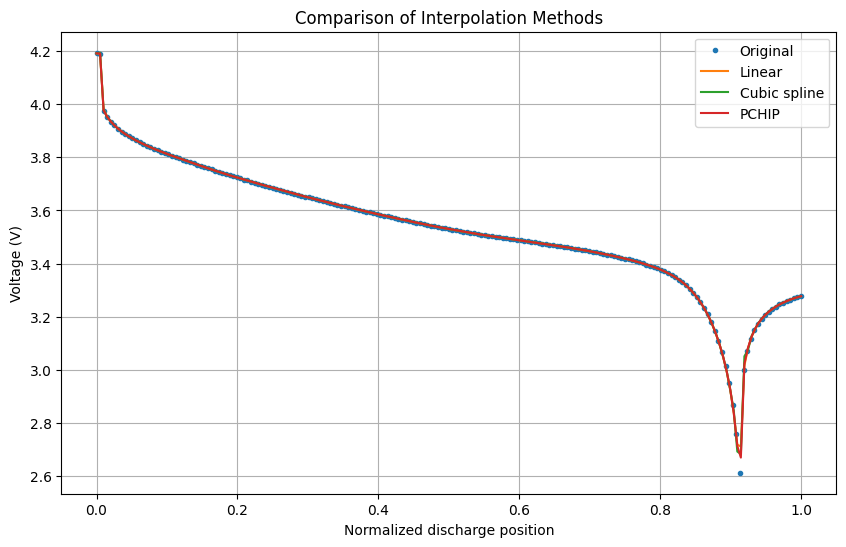

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    old_grid,
    voltage,
    "o",
    markersize=3,
    label="Original"
)

plt.plot(
    new_grid,
    voltage_linear,
    label="Linear"
)

plt.plot(
    new_grid,
    voltage_cubic,
    label="Cubic spline"
)

plt.plot(
    new_grid,
    voltage_pchip,
    label="PCHIP"
)

plt.xlabel("Normalized discharge position")
plt.ylabel("Voltage (V)")
plt.title("Comparison of Interpolation Methods")
plt.legend()
plt.grid()

plt.show()

**7E — BUILD A COMMON GRID FOR ALL CYCLES**

## 7E — Applying interpolation to all discharge cycles

We now repeat the same idea for every discharge cycle.

We normalize the position of each cycle from 0 to 1.

This gives every cycle a common independent variable:

0 → beginning of discharge

1 → end of discharge

We then evaluate every curve on:

N = 200

equally spaced points.

This produces a matrix:

number of cycles × 200

Each row represents one discharge cycle.

In [ ]:
N = 200

common_grid = np.linspace(0, 1, N)

X_linear = []

for cycle in discharge_cycles:

    cycle_data = cycle["data"]

    voltage = np.asarray(
        cycle_data["Voltage_measured"].ravel()[0],
        dtype=float
    ).ravel()

    old_grid = np.linspace(0, 1, len(voltage))

    voltage_new = np.interp(
        common_grid,
        old_grid,
        voltage
    )

    X_linear.append(voltage_new)

X_linear = np.array(X_linear)

print("Interpolated matrix shape:", X_linear.shape)
print("NaNs:", np.isnan(X_linear).sum())

Interpolated matrix shape: (168, 200)
NaNs: 0


**7F — PCHIP FOR ALL CYCLES**

In [ ]:
X_pchip = []

for cycle in discharge_cycles:

    cycle_data = cycle["data"]

    voltage = np.asarray(
        cycle_data["Voltage_measured"].ravel()[0],
        dtype=float
    ).ravel()

    old_grid = np.linspace(0, 1, len(voltage))

    pchip_function = PchipInterpolator(
        old_grid,
        voltage
    )

    voltage_new = pchip_function(common_grid)

    X_pchip.append(voltage_new)

X_pchip = np.array(X_pchip)

print("PCHIP matrix shape:", X_pchip.shape)
print("NaNs:", np.isnan(X_pchip).sum())

PCHIP matrix shape: (168, 200)
NaNs: 0


#End of Part 1